In [2]:
# 필요한 라이브러리 불러오기
import pandas as pd

# CSV 파일 로드 (notebooks 폴더 기준 상대경로)
df = pd.read_csv('../data/smart_logistics_dataset.csv')

# 기본 정보 확인: 행/열 개수
print("데이터 크기 (행, 열):", df.shape)

# 컬럼별 데이터 타입과 결측치 개수 확인
df.info()

# 상위 5개 행 미리보기
df.head()

데이터 크기 (행, 열): (1000, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Timestamp                1000 non-null   object 
 1   Asset_ID                 1000 non-null   object 
 2   Latitude                 1000 non-null   float64
 3   Longitude                1000 non-null   float64
 4   Inventory_Level          1000 non-null   int64  
 5   Shipment_Status          1000 non-null   object 
 6   Temperature              1000 non-null   float64
 7   Humidity                 1000 non-null   float64
 8   Traffic_Status           1000 non-null   object 
 9   Waiting_Time             1000 non-null   int64  
 10  User_Transaction_Amount  1000 non-null   int64  
 11  User_Purchase_Frequency  1000 non-null   int64  
 12  Logistics_Delay_Reason   737 non-null    object 
 13  Asset_Utilization        1000 non-null   float64
 14 

,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,320,4,NaN,60.1,285,1
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,439,7,Weather,80.9,174,1
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,355,3,NaN,99.2,260,0
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,227,5,Traffic,97.4,160,1
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,197,6,NaN,71.6,270,1


## 데이터 컬럼 설명 (Smart Logistics Supply Chain Dataset)

| 컬럼명 (Column) | 한국어 | 데이터 타입 | 설명 |
|---|---|---|---|
| Timestamp | 타임스탬프 | object | 기록이 발생한 날짜/시간 |
| Asset_ID | 자산 ID | object | 트럭 등 물류 자산의 고유 식별자 (예: Truck_7) |
| Latitude | 위도 | float64 | 자산의 현재 위치 좌표(위도) |
| Longitude | 경도 | float64 | 자산의 현재 위치 좌표(경도) |
| Inventory_Level | 재고 수준 | int64 | 해당 시점의 재고 수량 (단위 불명 — 추측) |
| Shipment_Status | 배송 상태 | object | 배송 진행 상태 (예: Delivered, Delayed, In Transit 등) |
| Temperature | 온도 | float64 | 화물/환경 온도 (콜드체인 관리용으로 추정 — 추측) |
| Humidity | 습도 | float64 | 화물/환경 습도 |
| Traffic_Status | 교통 상황 | object | 배송 경로의 실시간 교통 상태 |
| Waiting_Time | 대기 시간 | int64 | 대기한 시간 (분 단위로 추정 — 추측) |
| User_Transaction_Amount | 고객 거래 금액 | int64 | 해당 주문/고객의 거래 금액 |
| User_Purchase_Frequency | 고객 구매 빈도 | int64 | 해당 고객의 구매 횟수 |
| Logistics_Delay_Reason | 물류 지연 사유 | object | 지연이 발생한 경우의 사유 (결측치 263건 — 지연 없는 건은 사유 없음으로 추정) |
| Asset_Utilization | 자산 가동률 | float64 | 자산(트럭 등)의 활용도/가동 비율 |
| Demand_Forecast | 수요 예측 | int64 | 예측된 수요량 |
| Logistics_Delay | 물류 지연 여부 | int64 | 지연 발생 여부 (0/1 이진값으로 추정 — 다음 단계에서 값 확인 필요) |

**참고**: `Inventory_Level`, `Temperature`, `Waiting_Time`, `Logistics_Delay` 등 단위/값 범위가 명확하지 않은 컬럼은 다음 탐색 단계(`.describe()`, `.unique()`)에서 실제 값을 확인하며 이 표를 업데이트하겠습니다.

In [3]:
# 결측치 발생 패턴 확인: 지연 사유가 없는 행들은 지연이 아닌지 대조
df[df['Logistics_Delay_Reason'].isnull()]['Logistics_Delay'].value_counts()

Logistics_Delay
1    147
0    116
Name: count, dtype: int64

결측치는 구조적(지연 아님=사유 없음)이 아닙니다. Logistics_Delay_Reason이 비어있는 263건 중 147건은 Logistics_Delay=1(지연 발생)인데도 사유가 비어있고, 116건만 Logistics_Delay=0(지연 아님)입니다. 지연이 발생했는데 사유가 없는 경우가 오히려 더 많습니다.실제 데이터 수집 과정에서 발생한 "진짜 결측"에 가깝습니다. 단순 삭제하면 지연 관련 정보 손실이 크고(147건이나 됨), 무작정 채우면 분석 왜곡 위험이 있습니다. 이번 분석 목적인 지연 현황 파악을 위해 지연 사유별 분석까지 시도해볼 수 있고 데이터도 온전히 보존하기 위해 Unknown 범주로 결측치 처리하겠습니다.

In [4]:
# Logistics_Delay_Reason의 결측치를 'Unknown'으로 채우기
# (지연 사유가 기록되지 않은 케이스도 하나의 정보로 남기기 위함)
df['Logistics_Delay_Reason'] = df['Logistics_Delay_Reason'].fillna('Unknown')

# 처리 후 결측치 재확인 (0이 나와야 정상)
print("결측치 개수:", df['Logistics_Delay_Reason'].isnull().sum())

# 채워진 후 값 분포 확인
df['Logistics_Delay_Reason'].value_counts()

결측치 개수: 0


Logistics_Delay_Reason
Weather               267
Unknown               263
Traffic               236
Mechanical Failure    234
Name: count, dtype: int64

In [5]:
# 1. 완전 중복 행 확인
print("중복 행 개수:", df.duplicated().sum())

# 2. 수치형 컬럼들의 기초 통계량으로 이상값 후보 탐색
df.describe()

중복 행 개수: 0


,Latitude,Longitude,Inventory_Level,Temperature,Humidity,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Asset_Utilization,Demand_Forecast,Logistics_Delay
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-1.360093,0.837049,297.915000,23.893900,65.042200,35.062000,299.055000,5.513000,79.599100,199.284000,0.566000
std,51.997183,104.843618,113.554773,3.322178,8.753765,14.477768,117.787792,2.935379,11.631153,59.920847,0.495873
min,-89.791500,-179.820200,100.000000,18.000000,50.000000,10.000000,100.000000,1.000000,60.000000,100.000000,0.000000
25%,-46.167975,-88.448075,201.000000,21.200000,57.200000,23.000000,191.750000,3.000000,69.475000,144.000000,0.000000
50%,-4.503150,0.678300,299.000000,23.800000,65.200000,35.000000,301.500000,6.000000,79.250000,202.000000,1.000000
75%,44.502800,88.156450,399.000000,26.600000,72.400000,49.000000,405.000000,8.000000,89.425000,251.250000,1.000000
max,89.870100,179.923700,500.000000,30.000000,80.000000,60.000000,500.000000,10.000000,100.000000,300.000000,1.000000


- 1000행 16열, 결측치는 Logistics_Delay_Reason뿐이었고 처리 완료
- 중복 행 없음, 이상값 없음
- 지연 비율 56.6%로 꽤 높음

In [6]:
# Timestamp를 datetime 타입으로 변환
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 변환 확인
print(df['Timestamp'].dtype)
print(df['Timestamp'].min(), "~", df['Timestamp'].max())

datetime64[ns]
2024-01-01 11:37:57 ~ 2024-12-30 20:21:58


In [7]:
# 분석에 쓸 파생 컬럼 생성
df['Hour'] = df['Timestamp'].dt.hour          # 시간대 (0~23)
df['Weekday'] = df['Timestamp'].dt.day_name() # 요일 (Monday~Sunday)
df['Month'] = df['Timestamp'].dt.month        # 월 (1~12)

# 결과 확인
df[['Timestamp', 'Hour', 'Weekday', 'Month']].head()

,Timestamp,Hour,Weekday,Month
0,2024-03-20 00:11:14,0,Wednesday,3
1,2024-10-30 07:53:51,7,Wednesday,10
2,2024-07-29 18:42:48,18,Monday,7
3,2024-10-28 00:50:54,0,Monday,10
4,2024-09-27 15:52:58,15,Friday,9


/var/folders/0y/2_jcn8qd6bd77x34yhlrz5qw0000gn/T/ipykernel_1657/1495619753.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reason_counts.index, y=reason_counts.values, palette='Set2')


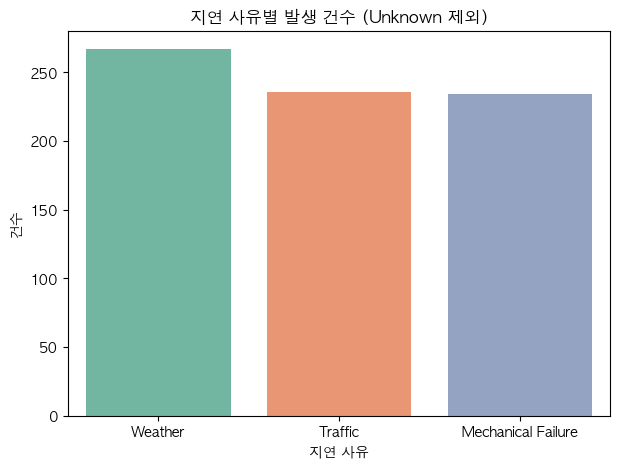

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한국어 폰트가 필요하면 Mac 기준 설정 (AppleGothic)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# Unknown 제외한 지연 사유 분포
reason_counts = df[df['Logistics_Delay_Reason'] != 'Unknown']['Logistics_Delay_Reason'].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=reason_counts.index, y=reason_counts.values, palette='Set2')
plt.title('지연 사유별 발생 건수 (Unknown 제외)')
plt.xlabel('지연 사유')
plt.ylabel('건수')
plt.show()

결론: 세 지연 사유(Weather, Traffic, Mechanical Failure)가 267/236/234건으로 거의 균등하게 분포되어 있습니다.
근거: 세 막대의 높이 차이가 크지 않고, 가장 많은 Weather와 가장 적은 Mechanical Failure의 차이도 33건(약 12%)에 불과합니다.
시사점: 지연이 특정 원인 하나에 쏠린 게 아니라 세 요인이 비슷한 비중으로 작용하고 있습니다. 즉, 물류 지연을 줄이려면 한 가지 대책(예: 교통 대응만)으로는 부족하고, 날씨·교통·설비 세 방면 모두를 고려한 다각적 접근이 필요하다는 시사점을 낼 수 있습니다.

## Traffic 관련 컬럼 분석

['Detour' 'Heavy' 'Clear']


/var/folders/0y/2_jcn8qd6bd77x34yhlrz5qw0000gn/T/ipykernel_1657/810896766.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=traffic_delay_rate.index, y=traffic_delay_rate.values, palette='Set2')


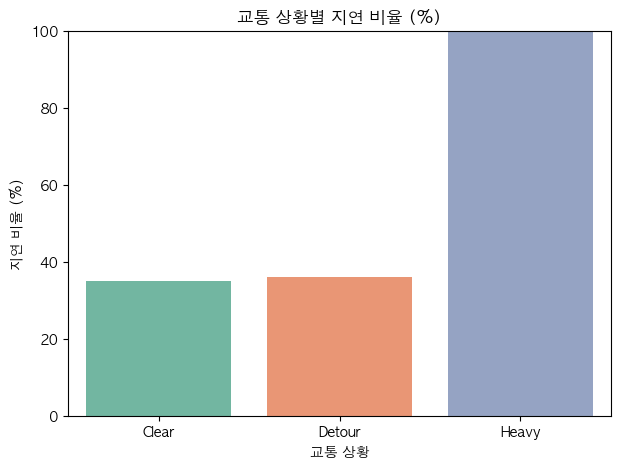

In [9]:
# 먼저 Traffic_Status의 고유값 확인 (예상치 못한 범주 있는지 체크)
print(df['Traffic_Status'].unique())

# 교통 상황별 지연 비율 계산
traffic_delay_rate = df.groupby('Traffic_Status')['Logistics_Delay'].mean() * 100

plt.figure(figsize=(7, 5))
sns.barplot(x=traffic_delay_rate.index, y=traffic_delay_rate.values, palette='Set2')
plt.title('교통 상황별 지연 비율 (%)')
plt.xlabel('교통 상황')
plt.ylabel('지연 비율 (%)')
plt.ylim(0, 100)
plt.show()

- Clear	원활	교통 정체 없이 원활하게 흐르는 상태
- Detour	우회	사고나 공사 등으로 우회로를 이용해야 하는 상태
- Heavy	정체(혼잡)	교통량이 많아 심하게 막히는 상태

결론: Heavy(정체) 상태일 때 지연 비율이 **100%**로, Clear(약 35%)나 Detour(약 36%)와는 차원이 다르게 높습니다.
근거: 그래프상 Heavy 막대만 100%에 도달했고, 나머지 둘은 35~36% 선에서 거의 비슷합니다.
시사점: 이전 D 결과에서 Traffic이 지연 사유의 1/3 정도(236건)만 차지했는데, 이 결과와 종합하면 **"교통이 Heavy 상태가 되면 사실상 무조건 지연으로 이어진다"**는 강한 인과관계로 해석할 수 있습니다. Clear/Detour는 지연 여부에 큰 차이를 안 만드는데 Heavy만 결정적이라는 점이 흥미롭습니다. 물류 운영 관점에서는 "Heavy 예측 시 사전 대응"이 지연 감소의 핵심 레버가 될 수 있습니다.

Heavy가 정확히 몇 건 중 100%인지(모수가 너무 작으면 신뢰도가 떨어짐) 확인을 진행합니다.

In [10]:
# 교통 상황별 전체 건수와 지연 건수 함께 확인
traffic_summary = df.groupby('Traffic_Status')['Logistics_Delay'].agg(['count', 'sum', 'mean'])
traffic_summary.columns = ['전체건수', '지연건수', '지연비율']
traffic_summary['지연비율'] = (traffic_summary['지연비율'] * 100).round(1)
traffic_summary

,전체건수,지연건수,지연비율
Traffic_Status,,,
Clear,328,115,35.1
Detour,345,124,35.9
Heavy,327,327,100.0


결론: 모수 문제 없습니다. Heavy도 327건으로 Clear(328건), Detour(345건)와 거의 동일한 규모입니다.
근거: 세 범주가 각각 327~345건으로 균등하게 분포되어 있고, Heavy 327건 전부가 지연(327/327=100%)으로 확인됩니다.
시사점: 표본 크기가 충분히 크고 균등하기 때문에 이전 결론("Heavy=지연 확정")은 통계적으로 신뢰할 수 있는 강한 패턴입니다. 우연이나 소수 표본의 왜곡이 아니라, 이 데이터셋 안에서는 사실상 규칙(Heavy → 100% 지연)에 가깝습니다.

           전체건수  지연건수  지연비율
Weekday                    
Monday      153    80  52.3
Tuesday     140    91  65.0
Wednesday   158    89  56.3
Thursday    135    75  55.6
Friday      147    79  53.7
Saturday    139    83  59.7
Sunday      128    69  53.9


/var/folders/0y/2_jcn8qd6bd77x34yhlrz5qw0000gn/T/ipykernel_1657/1901761281.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekday_summary.index, y=weekday_summary['지연비율'], palette='Set2')


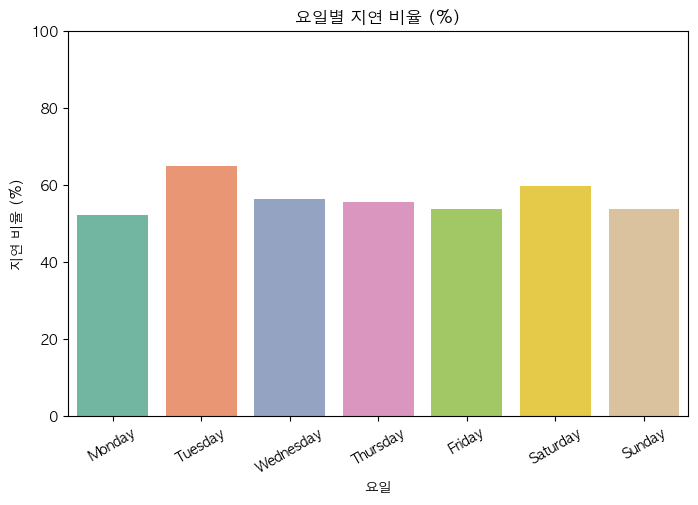

In [11]:
# 요일 순서를 명시적으로 지정 (월요일부터 일요일까지)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 요일별 전체건수, 지연건수, 지연비율 확인
weekday_summary = df.groupby('Weekday')['Logistics_Delay'].agg(['count', 'sum', 'mean']).reindex(weekday_order)
weekday_summary.columns = ['전체건수', '지연건수', '지연비율']
weekday_summary['지연비율'] = (weekday_summary['지연비율'] * 100).round(1)
print(weekday_summary)

# 시각화
plt.figure(figsize=(8, 5))
sns.barplot(x=weekday_summary.index, y=weekday_summary['지연비율'], palette='Set2')
plt.title('요일별 지연 비율 (%)')
plt.xlabel('요일')
plt.ylabel('지연 비율 (%)')
plt.ylim(0, 100)
plt.xticks(rotation=30)
plt.show()

결론: 요일 간 지연 비율 차이가 크지 않습니다. 52~65% 사이로 전체 평균(56.6%)에서 크게 벗어나지 않습니다.
근거: 가장 낮은 Monday(약 52%)와 가장 높은 Tuesday(약 65%)의 차이가 13%p 정도로, C(Heavy vs Clear, 65%p 차이)에 비하면 훨씬 미미합니다.
시사점: 요일은 지연에 큰 영향을 주는 요인이 아닙니다. Tuesday가 살짝 높게 나오지만, 이 정도 차이는 우연(표본 변동)일 가능성도 배제할 수 없어(추측입니다), 이 하나만으로 "화요일엔 지연이 잦다"고 단정하기는 이릅니다. 물류 지연 대응 전략에서 요일별 접근보다는 앞서 확인한 교통 상황(Heavy) 같은 요인에 집중하는 게 더 효과적일 것으로 보입니다.

      전체건수  지연건수  지연비율
Hour                  
0       47    25  53.2
1       35    19  54.3
2       39    20  51.3
3       43    24  55.8
4       43    28  65.1
5       33    15  45.5
6       36    21  58.3
7       34    17  50.0
8       50    32  64.0
9       44    21  47.7
10      58    31  53.4
11      42    23  54.8
12      55    33  60.0
13      32    18  56.2
14      43    29  67.4
15      40    25  62.5
16      40    22  55.0
17      36    25  69.4
18      44    20  45.5
19      34    21  61.8
20      38    23  60.5
21      46    28  60.9
22      48    21  43.8
23      40    25  62.5


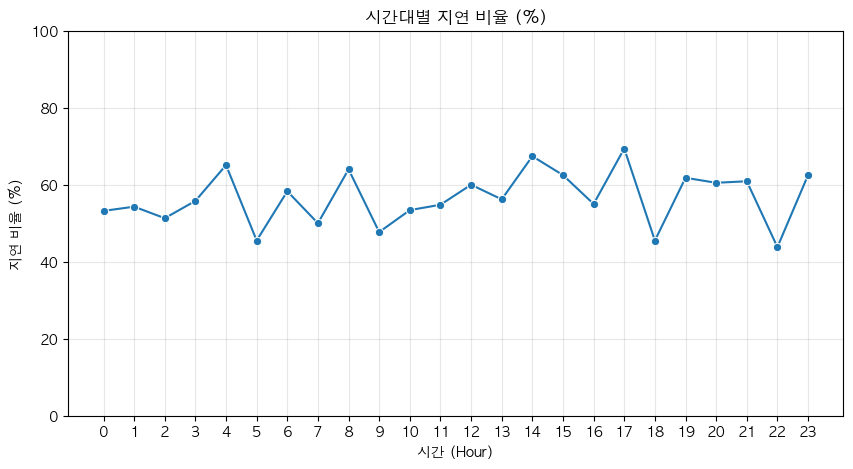

In [12]:
# 시간대별 전체건수, 지연건수, 지연비율 확인
hour_summary = df.groupby('Hour')['Logistics_Delay'].agg(['count', 'sum', 'mean'])
hour_summary.columns = ['전체건수', '지연건수', '지연비율']
hour_summary['지연비율'] = (hour_summary['지연비율'] * 100).round(1)
print(hour_summary)

# 시각화 (선그래프)
plt.figure(figsize=(10, 5))
sns.lineplot(x=hour_summary.index, y=hour_summary['지연비율'], marker='o')
plt.title('시간대별 지연 비율 (%)')
plt.xlabel('시간 (Hour)')
plt.ylabel('지연 비율 (%)')
plt.xticks(range(0, 24))
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.show()

결론: 시간대별 지연 비율은 44%~70% 사이에서 오르내리지만, 뚜렷한 패턴(예: 출퇴근 시간 급등, 심야 시간 급락 같은)은 보이지 않습니다.
근거: 요일별(B, 52~65%, 13%p 차이)과 비교해 시간대별(A, 44~70%, 26%p 차이)이 변동폭 자체는 좀 더 크지만, 이게 "패턴"이라기보다는 톱니처럼 오르락내리락하는 모양이라 특정 시간대가 체계적으로 높거나 낮다고 보기 어렵습니다. 예를 들어 17시(약 70%)가 높다가 바로 18시(약 46%)로 급락하는데, 이런 급격한 인접 시간대 반전은 실제 원인이 있는 패턴이라기보다 표본 변동(noise)에 가깝습니다.
시사점:  "시간당 표본이 작아 변동폭이 클 것"이라 예상했는데, 실제로는 변동은 있지만 육안으로 "특별히 크다"고 판단할 정도는 아닌 것으로 확인되었습니다. 종합하면 시간대(A)와 요일(B) 둘 다 지연에 유의미한 영향을 주는 요인은 아니고, C(교통 상황, 특히 Heavy)만이 지연을 결정짓는 압도적 요인으로 보입니다.

          전체건수  지연건수  지연비율
Day_Type                  
Weekday    733   414  56.5
Weekend    267   152  56.9


/var/folders/0y/2_jcn8qd6bd77x34yhlrz5qw0000gn/T/ipykernel_1657/1036162717.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=daytype_summary.index, y=daytype_summary['지연비율'], palette='Set2')


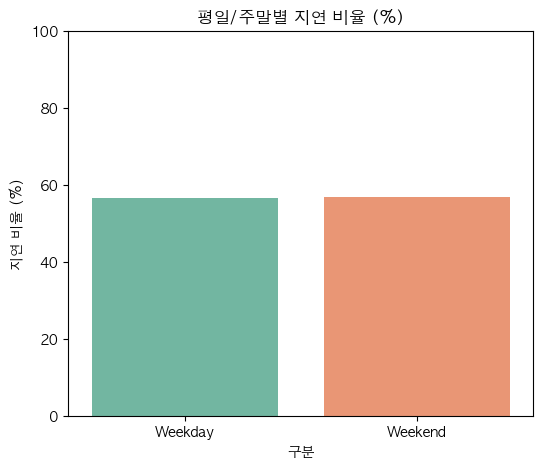

In [13]:
# 평일/주말 구분 컬럼 생성
df['Is_Weekend'] = df['Weekday'].isin(['Saturday', 'Sunday'])
df['Day_Type'] = df['Is_Weekend'].map({True: 'Weekend', False: 'Weekday'})

# 평일/주말별 전체건수, 지연건수, 지연비율 확인
daytype_summary = df.groupby('Day_Type')['Logistics_Delay'].agg(['count', 'sum', 'mean'])
daytype_summary.columns = ['전체건수', '지연건수', '지연비율']
daytype_summary['지연비율'] = (daytype_summary['지연비율'] * 100).round(1)
print(daytype_summary)

# 시각화
plt.figure(figsize=(6, 5))
sns.barplot(x=daytype_summary.index, y=daytype_summary['지연비율'], palette='Set2')
plt.title('평일/주말별 지연 비율 (%)')
plt.xlabel('구분')
plt.ylabel('지연 비율 (%)')
plt.ylim(0, 100)
plt.show()

요일 요인(B)에 이어 평일/주말 구분(이번 분석)까지도 지연에 영향을 주지 않는다는 게 재확인됐습니다. 이 데이터셋에서 시간 관련 요인(시간대, 요일, 평일/주말)은 모두 지연과 무관하고, 오직 교통 상황(C, 특히 Heavy)만이 지연을 결정짓는 요인이라는 결론

## Weather관련 분석

상관계수:
Temperature       -0.038067
Humidity          -0.000504
Logistics_Delay    1.000000
Name: Logistics_Delay, dtype: float64

온도 구간별 지연 비율:
             건수  지연비율
Temp_Group           
저온          328  58.5
중온          373  56.3
고온          299  54.8

습도 구간별 지연 비율:
                 건수  지연비율
Humidity_Group           
저습              334  57.2
중습              329  57.1
고습              337  55.5


/var/folders/0y/2_jcn8qd6bd77x34yhlrz5qw0000gn/T/ipykernel_1657/2598985987.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_delay = df.groupby('Temp_Group')['Logistics_Delay'].agg(['count', 'mean'])
/var/folders/0y/2_jcn8qd6bd77x34yhlrz5qw0000gn/T/ipykernel_1657/2598985987.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  humidity_delay = df.groupby('Humidity_Group')['Logistics_Delay'].agg(['count', 'mean'])
/var/folders/0y/2_jcn8qd6bd77x34yhlrz5qw0000gn/T/ipykernel_1657/2598985987.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assig

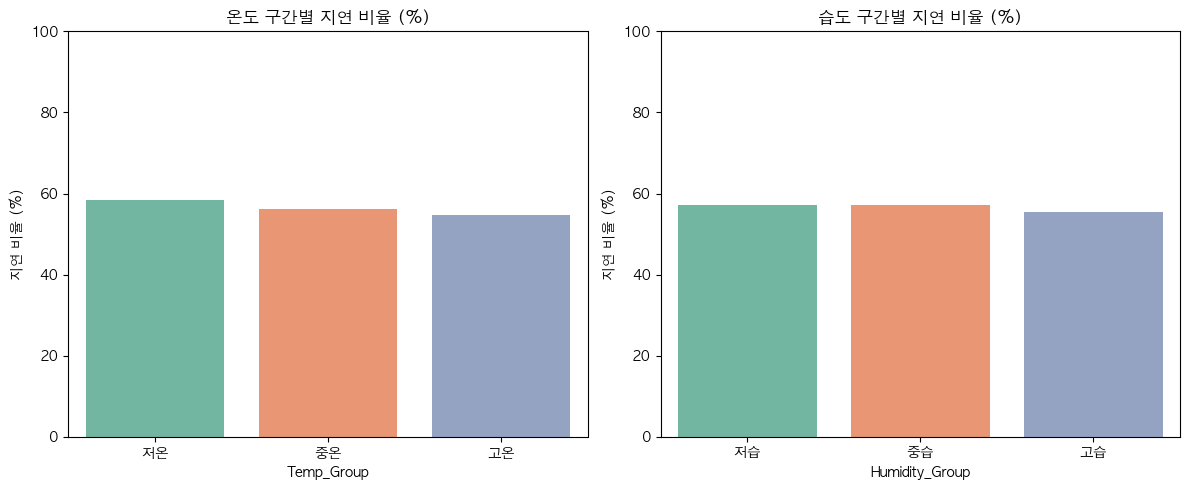

In [14]:
# 1. 상관계수 확인 (선형 관계 파악)
correlation = df[['Temperature', 'Humidity', 'Logistics_Delay']].corr()
print("상관계수:")
print(correlation['Logistics_Delay'])

# 2. Temperature를 3구간(저/중/고)으로 나누기
df['Temp_Group'] = pd.cut(df['Temperature'], bins=3, labels=['저온', '중온', '고온'])

# 3. Humidity를 3구간(저/중/고)으로 나누기
df['Humidity_Group'] = pd.cut(df['Humidity'], bins=3, labels=['저습', '중습', '고습'])

# 4. 구간별 지연 비율 계산
temp_delay = df.groupby('Temp_Group')['Logistics_Delay'].agg(['count', 'mean'])
temp_delay.columns = ['건수', '지연비율']
temp_delay['지연비율'] = (temp_delay['지연비율'] * 100).round(1)

humidity_delay = df.groupby('Humidity_Group')['Logistics_Delay'].agg(['count', 'mean'])
humidity_delay.columns = ['건수', '지연비율']
humidity_delay['지연비율'] = (humidity_delay['지연비율'] * 100).round(1)

print("\n온도 구간별 지연 비율:")
print(temp_delay)
print("\n습도 구간별 지연 비율:")
print(humidity_delay)

# 5. 시각화 (온도, 습도 나란히)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=temp_delay.index, y=temp_delay['지연비율'], palette='Set2', ax=axes[0])
axes[0].set_title('온도 구간별 지연 비율 (%)')
axes[0].set_ylabel('지연 비율 (%)')
axes[0].set_ylim(0, 100)

sns.barplot(x=humidity_delay.index, y=humidity_delay['지연비율'], palette='Set2', ax=axes[1])
axes[1].set_title('습도 구간별 지연 비율 (%)')
axes[1].set_ylabel('지연 비율 (%)')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [15]:
# 실제로 어떻게 나뉘었는지 확인
print(pd.cut(df['Temperature'], bins=3).unique())

[(26.0, 30.0], (22.0, 26.0], (17.988, 22.0]]
Categories (3, interval[float64, right]): [(17.988, 22.0] < (22.0, 26.0] < (26.0, 30.0]]


결론: Temperature와 Humidity 모두 지연과 관계가 거의 없습니다. C(교통상황)에서 본 강력한 관계와는 완전히 다릅니다.
근거: 상관계수가 각각 -0.038, -0.0005로 0에 매우 가깝습니다(±0.1 미만이면 사실상 무관계로 봅니다). 구간별 지연 비율도 저온 58.5% → 고온 54.8%, 저습 57.2% → 고습 55.5%로 차이가 3~4%p에 불과해 U자형 패턴도 없습니다.
시사점: D에서 확인했던 "Weather가 지연 사유의 267건(가장 큰 비중)을 차지한다"는 사실과 실제 수치 데이터로 검증했을 때 괴리가 있었습니다.

## Mechanical Failure 관련 분석

상관계수:
Asset_Utilization   -0.00314
Logistics_Delay      1.00000
Name: Logistics_Delay, dtype: float64

자산 가동률 구간별 지연 비율:
             건수  지연비율
Util_Group           
저가동         362  56.9
중가동         302  54.3
고가동         336  58.3


/var/folders/0y/2_jcn8qd6bd77x34yhlrz5qw0000gn/T/ipykernel_1657/2886158873.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  util_delay = df.groupby('Util_Group')['Logistics_Delay'].agg(['count', 'mean'])
/var/folders/0y/2_jcn8qd6bd77x34yhlrz5qw0000gn/T/ipykernel_1657/2886158873.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=util_delay.index, y=util_delay['지연비율'], palette='Set2')


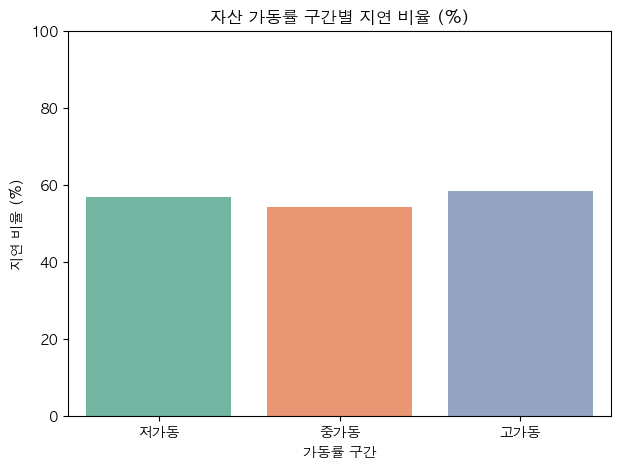

In [16]:
# 1. 상관계수 확인
correlation2 = df[['Asset_Utilization', 'Logistics_Delay']].corr()
print("상관계수:")
print(correlation2['Logistics_Delay'])

# 2. Asset_Utilization을 3구간으로 나누기
df['Util_Group'] = pd.cut(df['Asset_Utilization'], bins=3, labels=['저가동', '중가동', '고가동'])

# 3. 구간별 지연 비율 계산
util_delay = df.groupby('Util_Group')['Logistics_Delay'].agg(['count', 'mean'])
util_delay.columns = ['건수', '지연비율']
util_delay['지연비율'] = (util_delay['지연비율'] * 100).round(1)
print("\n자산 가동률 구간별 지연 비율:")
print(util_delay)

# 4. 시각화
plt.figure(figsize=(7, 5))
sns.barplot(x=util_delay.index, y=util_delay['지연비율'], palette='Set2')
plt.title('자산 가동률 구간별 지연 비율 (%)')
plt.xlabel('가동률 구간')
plt.ylabel('지연 비율 (%)')
plt.ylim(0, 100)
plt.show()

## Inventory_Level, Shipment_Status, Asset_ID, Demand_Forecast 관련 분석

상관계수:
Inventory_Level   -0.00334
Logistics_Delay    1.00000
Name: Logistics_Delay, dtype: float64

재고 수준 구간별 지연 비율:
                  건수  지연비율
Inventory_Group           
저재고              335  61.2
중재고              346  50.6
고재고              319  58.3


/var/folders/0y/2_jcn8qd6bd77x34yhlrz5qw0000gn/T/ipykernel_1657/2904802774.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inv_delay = df.groupby('Inventory_Group')['Logistics_Delay'].agg(['count', 'mean'])
/var/folders/0y/2_jcn8qd6bd77x34yhlrz5qw0000gn/T/ipykernel_1657/2904802774.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=inv_delay.index, y=inv_delay['지연비율'], palette='Set2')


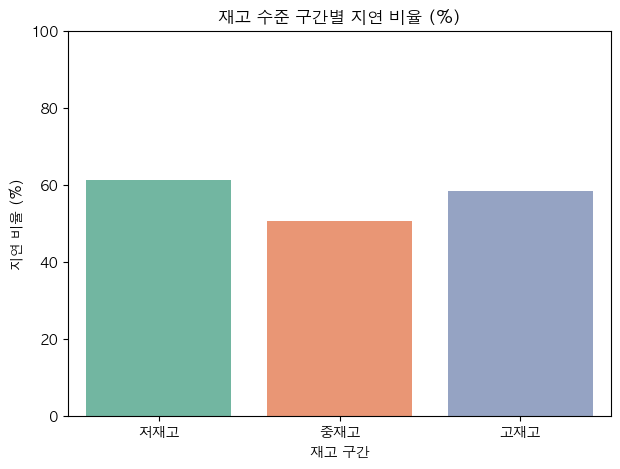

In [17]:
# 1. 상관계수 확인
correlation3 = df[['Inventory_Level', 'Logistics_Delay']].corr()
print("상관계수:")
print(correlation3['Logistics_Delay'])

# 2. Inventory_Level을 3구간으로 나누기
df['Inventory_Group'] = pd.cut(df['Inventory_Level'], bins=3, labels=['저재고', '중재고', '고재고'])

# 3. 구간별 지연 비율 계산
inv_delay = df.groupby('Inventory_Group')['Logistics_Delay'].agg(['count', 'mean'])
inv_delay.columns = ['건수', '지연비율']
inv_delay['지연비율'] = (inv_delay['지연비율'] * 100).round(1)
print("\n재고 수준 구간별 지연 비율:")
print(inv_delay)

# 4. 시각화
plt.figure(figsize=(7, 5))
sns.barplot(x=inv_delay.index, y=inv_delay['지연비율'], palette='Set2')
plt.title('재고 수준 구간별 지연 비율 (%)')
plt.xlabel('재고 구간')
plt.ylabel('지연 비율 (%)')
plt.ylim(0, 100)
plt.show()

In [18]:
# 1. Shipment_Status의 고유값과 각각의 개수 확인
print(df['Shipment_Status'].value_counts())

# 2. Shipment_Status별 실제 지연(Logistics_Delay) 비율 대조
status_delay = df.groupby('Shipment_Status')['Logistics_Delay'].agg(['count', 'mean'])
status_delay.columns = ['건수', '지연비율']
status_delay['지연비율'] = (status_delay['지연비율'] * 100).round(1)
print("\n배송 상태별 지연 비율:")
print(status_delay)

Shipment_Status
Delayed       350
Delivered     338
In Transit    312
Name: count, dtype: int64

배송 상태별 지연 비율:
                  건수   지연비율
Shipment_Status            
Delayed          350  100.0
Delivered        338   34.9
In Transit       312   31.4


결론: Shipment_Status의 "Delayed" 값은 Logistics_Delay와 완전히 중복된 정보입니다.
근거: Delayed 상태인 350건 전부(100%)가 Logistics_Delay=1입니다. 즉 "Delayed"라는 배송 상태 자체가 곧 지연 발생을 의미하며, 별도로 대조할 필요 없이 같은 사실을 다르게 표현한 것뿐입니다.
시사점: Shipment_Status는 지연의 "원인 요인"이 아니라 Logistics_Delay와 같은 층위의 결과 지표입니다. 이 컬럼을 지연 원인 분석에 넣으면 안 되고(같은 걸 같은 것과 비교하는 셈), 오히려 나중에 예측 모델을 만들 때는 이 컬럼이 정답을 미리 알려주는 "정보 누출(data leakage)"이 될 수 있어 제외해야 합니다.

['Truck_7' 'Truck_6' 'Truck_10' 'Truck_9' 'Truck_4' 'Truck_2' 'Truck_8'
 'Truck_3' 'Truck_5' 'Truck_1']
총 자산 개수: 10

자산별 지연 비율 (내림차순):
           건수  지연비율
Asset_ID           
Truck_10  105  64.8
Truck_3    93  62.4
Truck_4   107  58.9
Truck_7   102  58.8
Truck_8   109  56.9
Truck_9    94  56.4
Truck_2   105  53.3
Truck_6   103  52.4
Truck_1    89  51.7
Truck_5    93  49.5


/var/folders/0y/2_jcn8qd6bd77x34yhlrz5qw0000gn/T/ipykernel_1657/3206498081.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=asset_delay.index, y=asset_delay['지연비율'], palette='Set2', order=asset_delay.index)


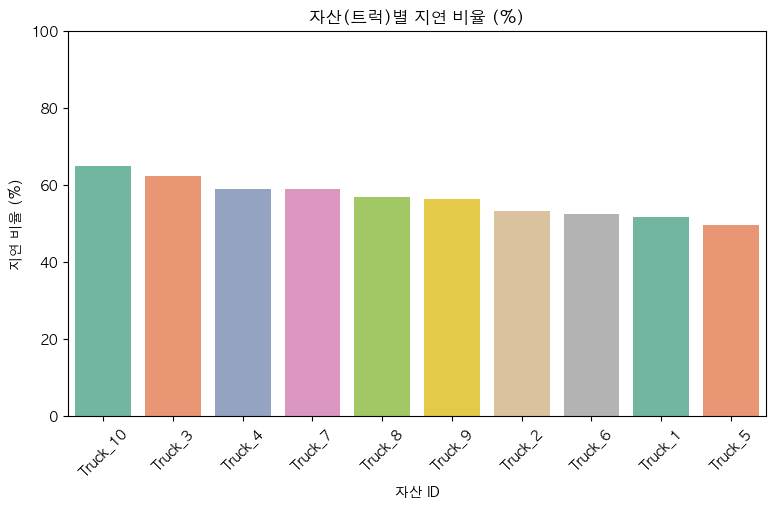

In [19]:
# Asset_ID 종류 먼저 확인
print(df['Asset_ID'].unique())
print("총 자산 개수:", df['Asset_ID'].nunique())

# Asset_ID별 전체건수, 지연건수, 지연비율
asset_delay = df.groupby('Asset_ID')['Logistics_Delay'].agg(['count', 'mean']).sort_values('mean', ascending=False)
asset_delay.columns = ['건수', '지연비율']
asset_delay['지연비율'] = (asset_delay['지연비율'] * 100).round(1)
print("\n자산별 지연 비율 (내림차순):")
print(asset_delay)

# 시각화
plt.figure(figsize=(9, 5))
sns.barplot(x=asset_delay.index, y=asset_delay['지연비율'], palette='Set2', order=asset_delay.index)
plt.title('자산(트럭)별 지연 비율 (%)')
plt.xlabel('자산 ID')
plt.ylabel('지연 비율 (%)')
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.show()

결론: 트럭 10대 모두 예상대로(추측이 맞음) 큰 차이 없이 고르게 분포합니다.
근거: 가장 높은 Truck_10(64.8%)과 가장 낮은 Truck_5(49.5%) 차이가 15.3%p로, C(Heavy vs Clear, 65%p 차이)에 비하면 미미한 수준입니다. B(요일), A(시간대)와 비슷한 정도의 자연스러운 변동 범위 안에 있습니다.
시사점: 특정 트럭에 고장/노후화 문제가 집중되어 있다고 보기는 어렵습니다. 각 트럭당 표본이 89~109건 수준이라 통계적으로 안정적인 비교이며, 이 정도 차이는 트럭 성능 차이라기보다 자연스러운 변동으로 해석하는 게 타당합니다.

상관계수:
Demand_Forecast   -0.018621
Logistics_Delay    1.000000
Name: Logistics_Delay, dtype: float64

수요 예측 구간별 지연 비율:
               건수  지연비율
Demand_Group           
저수요           358  57.8
중수요           290  56.6
고수요           352  55.4


/var/folders/0y/2_jcn8qd6bd77x34yhlrz5qw0000gn/T/ipykernel_1657/1805005247.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demand_delay = df.groupby('Demand_Group')['Logistics_Delay'].agg(['count', 'mean'])
/var/folders/0y/2_jcn8qd6bd77x34yhlrz5qw0000gn/T/ipykernel_1657/1805005247.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=demand_delay.index, y=demand_delay['지연비율'], palette='Set2')


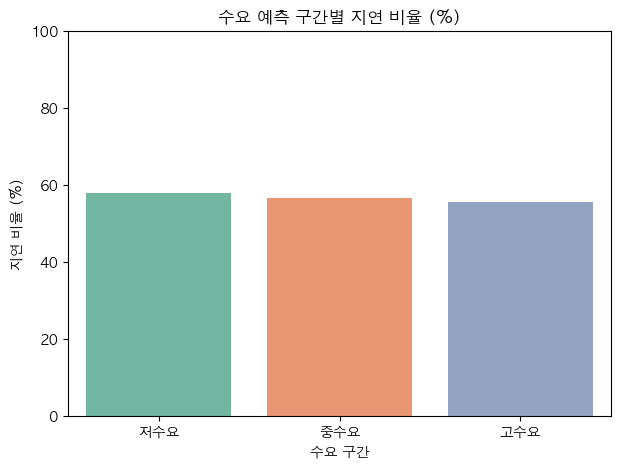

In [20]:
# 1. 상관계수 확인
correlation4 = df[['Demand_Forecast', 'Logistics_Delay']].corr()
print("상관계수:")
print(correlation4['Logistics_Delay'])

# 2. Demand_Forecast를 3구간으로 나누기
df['Demand_Group'] = pd.cut(df['Demand_Forecast'], bins=3, labels=['저수요', '중수요', '고수요'])

# 3. 구간별 지연 비율 계산
demand_delay = df.groupby('Demand_Group')['Logistics_Delay'].agg(['count', 'mean'])
demand_delay.columns = ['건수', '지연비율']
demand_delay['지연비율'] = (demand_delay['지연비율'] * 100).round(1)
print("\n수요 예측 구간별 지연 비율:")
print(demand_delay)

# 4. 시각화
plt.figure(figsize=(7, 5))
sns.barplot(x=demand_delay.index, y=demand_delay['지연비율'], palette='Set2')
plt.title('수요 예측 구간별 지연 비율 (%)')
plt.xlabel('수요 구간')
plt.ylabel('지연 비율 (%)')
plt.ylim(0, 100)
plt.show()

결론: Demand_Forecast도 지연과 무관합니다.
근거: 상관계수 -0.019로 0에 가깝고, 구간별 지연비율도 55.4~57.8%로 거의 동일합니다.

이 분석의 핵심 인사이트 3가지

Traffic_Status(교통 정체)가 사실상 유일하게 지연을 결정짓는 요인입니다. Heavy 상태면 예외 없이 100% 지연으로 이어집니다.
지연 "사유" 라벨(Weather, Mechanical Failure)은 실제 관련 수치 데이터와 상관관계가 없습니다. 이는 데이터의 신뢰성 문제이거나, 사유 기록이 실제 원인과 다르게 형식적으로 입력됐을 가능성을 시사합니다.
시간(시간대/요일/평일주말), 자산(트럭 개별), 수요, 재고 등 8개 요인 모두 지연과 무관하여, 지연 예방 노력을 교통 상황 대응(우회 경로, 실시간 교통 모니터링)에 집중하는 것이 가장 효과적이라는 실무적 시사점을 도출할 수 있습니다.

전체 평균:
Temperature    23.89
Humidity       65.04
dtype: float64

Weather 사유 건 평균:
Temperature    23.96
Humidity       64.49
dtype: float64

건수: 267


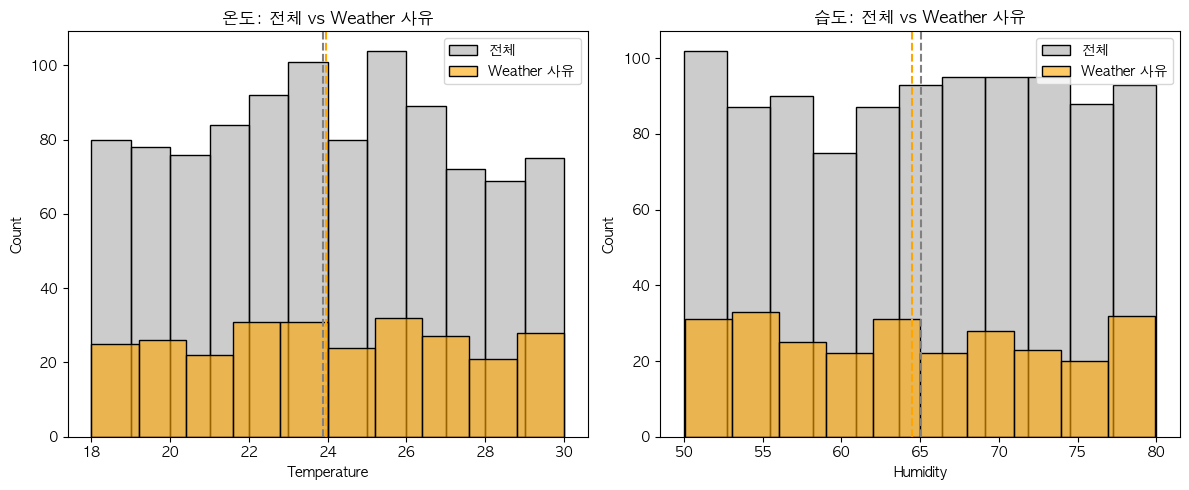

In [21]:
# 전체 데이터의 평균 온도/습도 (기준값)
overall_mean = df[['Temperature', 'Humidity']].mean().round(2)
print("전체 평균:")
print(overall_mean)

# Weather 사유로 기록된 건만 필터링
weather_df = df[df['Logistics_Delay_Reason'] == 'Weather']
weather_mean = weather_df[['Temperature', 'Humidity']].mean().round(2)
print("\nWeather 사유 건 평균:")
print(weather_mean)

print("\n건수:", len(weather_df))

# 시각화: Weather 건의 온도 분포를 전체 분포와 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['Temperature'], color='gray', alpha=0.4, label='전체', ax=axes[0])
sns.histplot(weather_df['Temperature'], color='orange', alpha=0.6, label='Weather 사유', ax=axes[0])
axes[0].axvline(overall_mean['Temperature'], color='gray', linestyle='--')
axes[0].axvline(weather_mean['Temperature'], color='orange', linestyle='--')
axes[0].set_title('온도: 전체 vs Weather 사유')
axes[0].legend()

sns.histplot(df['Humidity'], color='gray', alpha=0.4, label='전체', ax=axes[1])
sns.histplot(weather_df['Humidity'], color='orange', alpha=0.6, label='Weather 사유', ax=axes[1])
axes[1].axvline(overall_mean['Humidity'], color='gray', linestyle='--')
axes[1].axvline(weather_mean['Humidity'], color='orange', linestyle='--')
axes[1].set_title('습도: 전체 vs Weather 사유')
axes[1].legend()

plt.tight_layout()
plt.show()

전체 평균 Asset_Utilization: 79.6
Mechanical Failure 사유 건 평균: 81.17
건수: 234


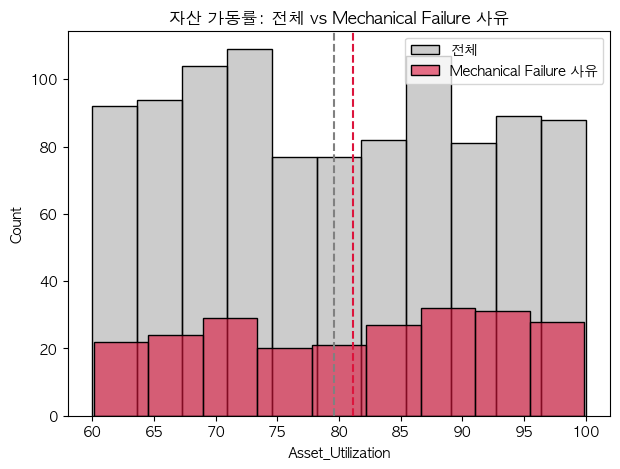

In [22]:
# 전체 데이터의 평균 자산 가동률 (기준값)
overall_mean_util = df['Asset_Utilization'].mean().round(2)
print("전체 평균 Asset_Utilization:", overall_mean_util)

# Mechanical Failure 사유로 기록된 건만 필터링
mech_df = df[df['Logistics_Delay_Reason'] == 'Mechanical Failure']
mech_mean_util = mech_df['Asset_Utilization'].mean().round(2)
print("Mechanical Failure 사유 건 평균:", mech_mean_util)
print("건수:", len(mech_df))

# 시각화: Mechanical Failure 건의 가동률 분포를 전체 분포와 비교
plt.figure(figsize=(7, 5))
sns.histplot(df['Asset_Utilization'], color='gray', alpha=0.4, label='전체')
sns.histplot(mech_df['Asset_Utilization'], color='crimson', alpha=0.6, label='Mechanical Failure 사유')
plt.axvline(overall_mean_util, color='gray', linestyle='--')
plt.axvline(mech_mean_util, color='crimson', linestyle='--')
plt.title('자산 가동률: 전체 vs Mechanical Failure 사유')
plt.xlabel('Asset_Utilization')
plt.legend()
plt.show()

In [23]:
# Weather 사유 여부를 0/1로 변환
df['Is_Weather'] = (df['Logistics_Delay_Reason'] == 'Weather').astype(int)

# Mechanical Failure 사유 여부를 0/1로 변환
df['Is_Mechanical'] = (df['Logistics_Delay_Reason'] == 'Mechanical Failure').astype(int)

# 상관계수 확인
print("Weather 사유와 Temperature/Humidity 상관계수:")
print(df[['Is_Weather', 'Temperature', 'Humidity']].corr()['Is_Weather'])

print("\nMechanical Failure 사유와 Asset_Utilization 상관계수:")
print(df[['Is_Mechanical', 'Asset_Utilization']].corr()['Is_Mechanical'])

Weather 사유와 Temperature/Humidity 상관계수:
Is_Weather     1.000000
Temperature    0.012001
Humidity      -0.037815
Name: Is_Weather, dtype: float64

Mechanical Failure 사유와 Asset_Utilization 상관계수:
Is_Mechanical        1.000000
Asset_Utilization    0.074466
Name: Is_Mechanical, dtype: float64


Temperature          0.046005
Humidity            -0.030637
Asset_Utilization    1.000000
Name: Asset_Utilization, dtype: float64


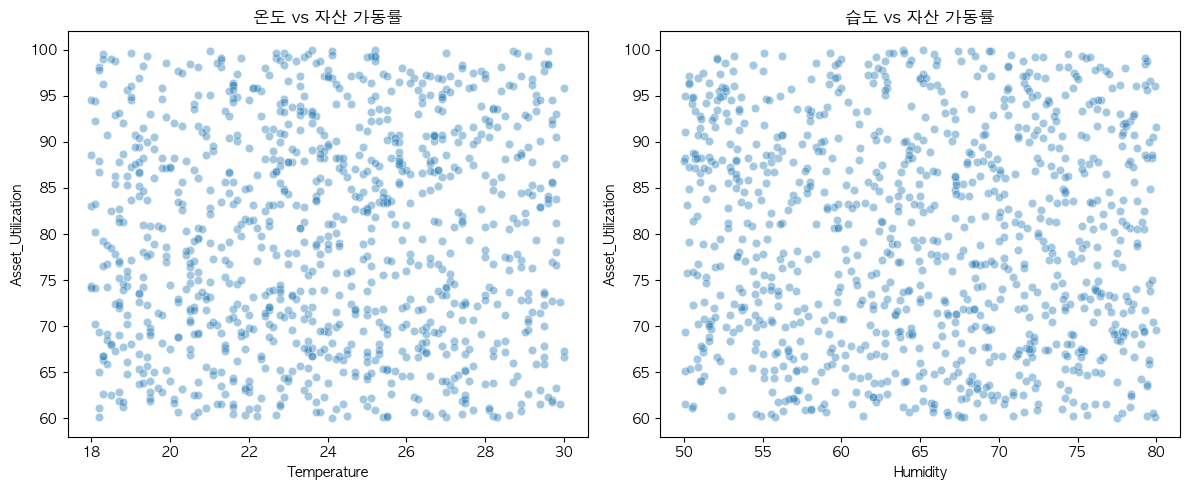

In [24]:
# 온도/습도와 자산 가동률 간의 상관관계
env_util_corr = df[['Temperature', 'Humidity', 'Asset_Utilization']].corr()
print(env_util_corr['Asset_Utilization'])

# 시각화로도 확인 (산점도)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=df, x='Temperature', y='Asset_Utilization', alpha=0.4, ax=axes[0])
axes[0].set_title('온도 vs 자산 가동률')

sns.scatterplot(data=df, x='Humidity', y='Asset_Utilization', alpha=0.4, ax=axes[1])
axes[1].set_title('습도 vs 자산 가동률')

plt.tight_layout()
plt.show()


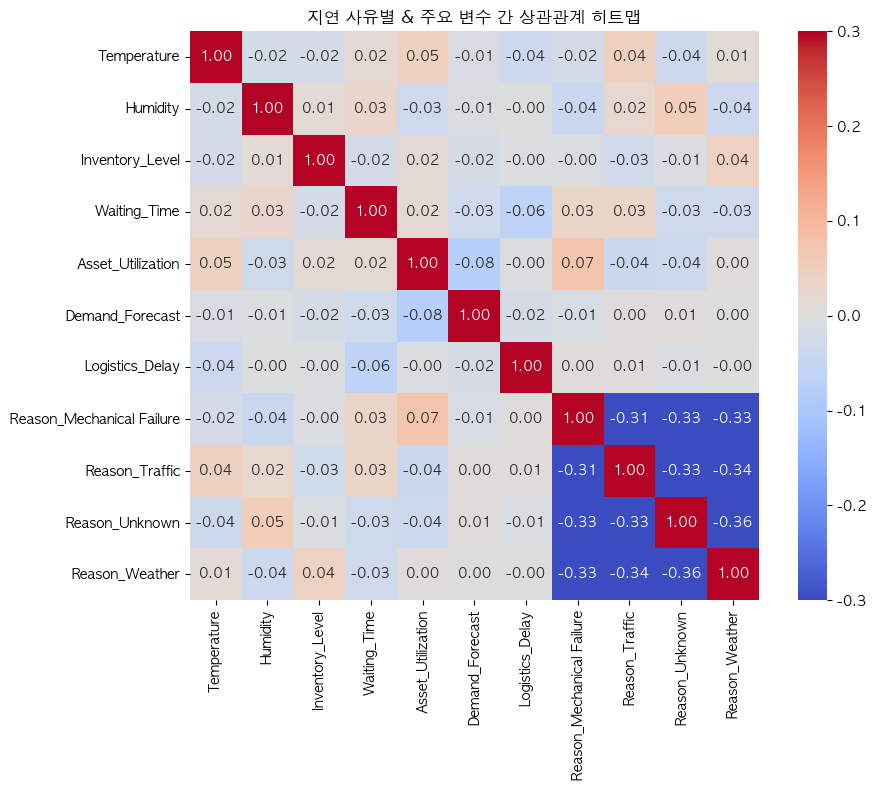

In [25]:
# 사유별 더미 변수 생성 (Unknown 포함)
reason_dummies = pd.get_dummies(df['Logistics_Delay_Reason'], prefix='Reason')

# 분석에 의미 있는 수치형 컬럼만 선정 (ID성/결과성 컬럼 제외)
numeric_cols = ['Temperature', 'Humidity', 'Inventory_Level', 'Waiting_Time',
                 'Asset_Utilization', 'Demand_Forecast', 'Logistics_Delay']

# 더미 변수 + 수치형 컬럼 합쳐서 상관관계 계산
corr_df = pd.concat([df[numeric_cols], reason_dummies], axis=1)
corr_matrix = corr_df.corr()

# 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            vmin=-0.3, vmax=0.3, square=True)
plt.title('지연 사유별 & 주요 변수 간 상관관계 히트맵')
plt.tight_layout()
plt.show()

시사점 : 연 사유 라벨은 실제 환경/자산 변수와 무관하다